In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

/home/student/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")

print(df.head())
print("Shape:", df.shape)
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
# Features and target
X = df.drop("quality", axis=1)
y = df["quality"]

print("Features:")
print(X.head())

print("\nTarget values:")
print(y.value_counts().sort_index())

Features:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape)
print("Testing samples:", X_test_scaled.shape)

Training samples: (1279, 11)
Testing samples: (320, 11)


In [5]:
architectures = {
    "1 Hidden Layer (10 neurons)": (10,),
    "1 Hidden Layer (50 neurons)": (50,),
    "2 Hidden Layers (50, 25)": (50, 25),
    "2 Hidden Layers (100, 50)": (100, 50),
    "3 Hidden Layers (100, 50, 25)": (100, 50, 25)
}

results = {}

for name, architecture in architectures.items():

    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(name)
    print("Accuracy:", round(accuracy, 4))
    print()

1 Hidden Layer (10 neurons)
Accuracy: 0.55

1 Hidden Layer (50 neurons)
Accuracy: 0.6062

2 Hidden Layers (50, 25)
Accuracy: 0.5875

2 Hidden Layers (100, 50)
Accuracy: 0.5844

3 Hidden Layers (100, 50, 25)
Accuracy: 0.6125



In [6]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Architecture", "Accuracy"]
)

print(results_df)

                    Architecture  Accuracy
0    1 Hidden Layer (10 neurons)  0.550000
1    1 Hidden Layer (50 neurons)  0.606250
2       2 Hidden Layers (50, 25)  0.587500
3      2 Hidden Layers (100, 50)  0.584375
4  3 Hidden Layers (100, 50, 25)  0.612500


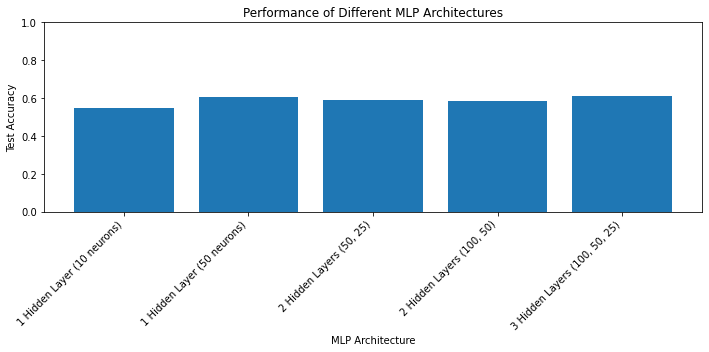

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Architecture"], results_df["Accuracy"])

plt.xlabel("MLP Architecture")
plt.ylabel("Test Accuracy")
plt.title("Performance of Different MLP Architectures")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
best_architecture = max(results, key=results.get)

print("Best Architecture:", best_architecture)
print("Best Accuracy:", results[best_architecture])

best_model = MLPClassifier(
    hidden_layer_sizes=architectures[best_architecture],
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best Architecture: 3 Hidden Layers (100, 50, 25)
Best Accuracy: 0.6125

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.65      0.74      0.69       136
           6       0.56      0.65      0.60       128
           7       0.72      0.33      0.45        40
           8       0.00      0.00      0.00         3

    accuracy                           0.61       320
   macro avg       0.32      0.28      0.29       320
weighted avg       0.59      0.61      0.59       320



/home/student/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/student/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
